## Decode the file first to view dataframe

+ Contains duplicates!! Check for it and remove them
+ Contains missing values
+ Has negative unit price, try to guess what could be the reason
+ Has negative quantity, try to guess what could be the reason

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\data.csv\data.csv",encoding = 'latin1')
#print(df.head())
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [12]:
df.duplicated().sum()
# Their are 5268 total duplicate value

np.int64(0)

In [11]:
df.drop_duplicates(inplace = True) #inplace overwrite the orginal

In [33]:
df.tail()
df.info()

<class 'pandas.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  str    
 1   StockCode    536641 non-null  str    
 2   Description  536641 non-null  str    
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  str    
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   536641 non-null  float64
 7   Country      536641 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 36.8 MB


In [12]:
df['Description'] = df['Description'].fillna('Unkown Product')

In [13]:
df['CustomerID'] = df['CustomerID'].fillna(999999999)

In [39]:
#print(df.isnull().sum())
#print(df['CustomerID'].info)
print(df[df['UnitPrice'] <= 0].head())

     InvoiceNo StockCode     Description  Quantity      InvoiceDate  \
622     536414     22139  Unkown Product        56  12/1/2010 11:52   
1970    536545     21134  Unkown Product         1  12/1/2010 14:32   
1971    536546     22145  Unkown Product         1  12/1/2010 14:33   
1972    536547     37509  Unkown Product         1  12/1/2010 14:33   
1987    536549    85226A  Unkown Product         1  12/1/2010 14:34   

      UnitPrice   CustomerID         Country  
622         0.0  999999999.0  United Kingdom  
1970        0.0  999999999.0  United Kingdom  
1971        0.0  999999999.0  United Kingdom  
1972        0.0  999999999.0  United Kingdom  
1987        0.0  999999999.0  United Kingdom  


In [40]:
print(df[df['Quantity'] <= 0].head())

    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

         InvoiceDate  UnitPrice  CustomerID         Country  
141   12/1/2010 9:41      27.50     14527.0  United Kingdom  
154   12/1/2010 9:49       4.65     15311.0  United Kingdom  
235  12/1/2010 10:24       1.65     17548.0  United Kingdom  
236  12/1/2010 10:24       0.29     17548.0  United Kingdom  
237  12/1/2010 10:24       0.29     17548.0  United Kingdom  


In [34]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [49]:
print(len(df[df['UnitPrice'] < 0]))
print(len(df[df['Quantity'] < 0]))

2
10587


In [14]:
# Keep only rows where both Quantity and UnitPrice are strictly positive
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"Cleaned sales records remaining: {len(df_sales)}")

Cleaned sales records remaining: 524878


In [15]:
print(df_sales[df_sales['UnitPrice'] == 0].head())
print(df_sales[df_sales['Quantity'] == 0].head())

Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country]
Index: []
Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country]
Index: []


In [28]:
df_return = df[(df['Quantity'] <= 0 ) & (df['UnitPrice'] <= 0)]
# Items given away for free
df_promotions = df[(df['Quantity'] > 0) & (df['UnitPrice'] == 0)]
# Anything where both are 0/negative, or price is negative
df_errors = df[(df['UnitPrice'] < 0) | ((df['Quantity'] <= 0) & (df['UnitPrice'] <= 0))]

1336


536641


In [27]:
print("Zero or Negative Quantities:", len(df[df['Quantity'] <= 0]))
print("Zero or Negative Unit Prices:", len(df[df['UnitPrice'] <= 0]))
print("Rows where BOTH are bad:", len(df[(df['Quantity'] <= 0) & (df['UnitPrice'] <= 0)]))

Zero or Negative Quantities: 10587
Zero or Negative Unit Prices: 2512
Rows where BOTH are bad: 1336


## Total Sales

In [30]:
df_sales['Revenue'] = df_sales['Quantity']*df_sales['UnitPrice']
total_sales = df_sales['Revenue'].sum()
print(total_sales)

10642110.804000001


## Top 5 sales according to product

In [39]:
top_products = df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head()
print(top_products)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
Name: Revenue, dtype: float64


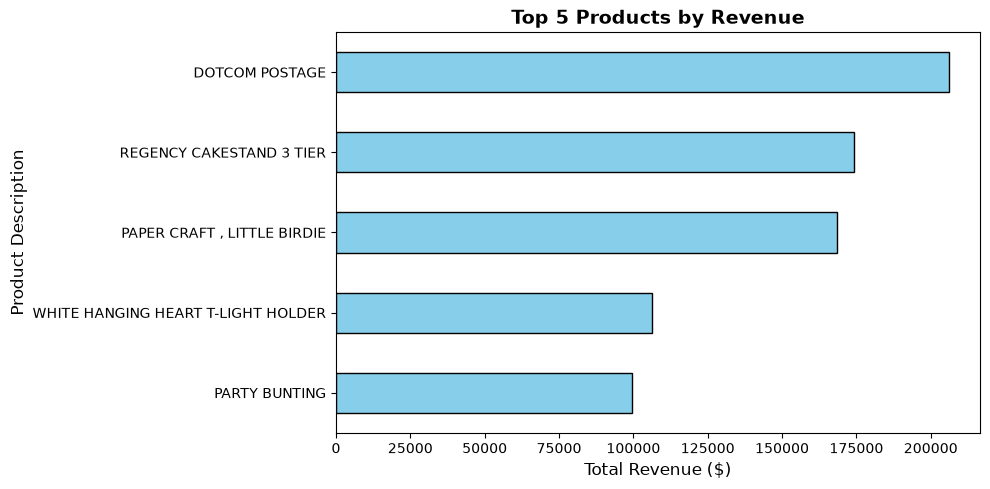

In [40]:
# 1. Prepare data

# 2. Plot
plt.figure(figsize=(10, 5))
top_products.sort_values(ascending=True).plot(kind='barh', color='skyblue', edgecolor='black')

# 3. Customize
plt.title('Top 5 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()

# 4. Show/Save
plt.savefig('top_products.png') # Saves the image for your GitHub
plt.show()

In [41]:
# Prepare the data
top_countries = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head()
print(top_countries)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Name: Revenue, dtype: float64


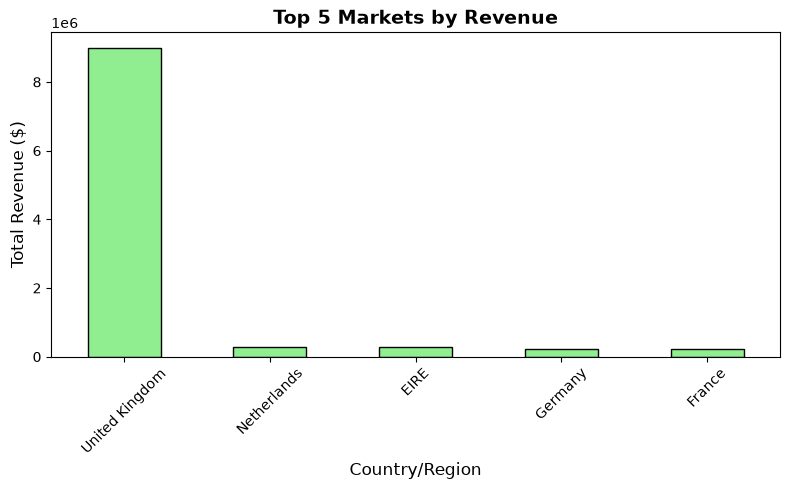

In [42]:

# 2. Plot
plt.figure(figsize=(8, 5))
top_countries.plot(kind='bar', color='lightgreen', edgecolor='black')

# 3. Customize
plt.title('Top 5 Markets by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Country/Region', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# 4. Show/Save
plt.savefig('top_markets.png')
plt.show()

In [29]:
df_sales.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')